# 02 — Experimental visualisations

## Purpose

Create dissertation-ready figures from **saved, auditable predictions and training histories**. This notebook contains no result values and should not perform inference. Implement reusable plot logic in `src/evaluation/plots.py`; use this notebook to select runs, add research context, and export figures with traceable filenames.

In [1]:
# Setup. This notebook only READS saved run outputs and calls the plotting functions in
# src.evaluation.plots. No metric is recomputed with different conventions here, and no
# model is loaded, so every figure traces back to a specific run directory.
%matplotlib inline
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.metrics import (
    compute_binary_metrics,
    confusion_matrix,
    precision_recall_curve_data,
    roc_curve_data,
    threshold_scores,
)
from src.evaluation.plots import (
    plot_confusion_matrix,
    plot_fine_tuning_recovery,
    plot_generator_performance,
    plot_precision_recall_curves,
    plot_roc_curves,
    plot_training_curves,
)

OUTPUT_ROOT = REPO_ROOT / "outputs"


def completed_runs(prefix):
    """Every completed run of one experiment type, oldest first."""
    found = []
    for path in sorted(OUTPUT_ROOT.glob(f"{prefix}-*")):
        status = path / "status.json"
        if status.is_file() and json.loads(status.read_text())["status"] == "completed":
            found.append(path)
    return found


def latest_run(prefix):
    runs = completed_runs(prefix)
    return runs[-1] if runs else None


def is_smoke(run):
    """Synthetic smoke runs must never be read as research results."""
    config = run / "resolved_config.yaml"
    return config.is_file() and "SMOKE" in config.read_text()


RUNS = {name: latest_run(name) for name in
        ("baseline", "unseen_generator", "fine_tuning", "ablation")}
for name, run in RUNS.items():
    if run is None:
        print(f"{name:18s} NO COMPLETED RUN")
    else:
        print(f"{name:18s} {run.name}{'   [SYNTHETIC SMOKE - NOT RESULTS]' if is_smoke(run) else ''}")

baseline           NO COMPLETED RUN
unseen_generator   unseen_generator-20260808T144550443491Z-b386ea5c10-bb06   [SYNTHETIC SMOKE - NOT RESULTS]
fine_tuning        fine_tuning-20260808T144640138049Z-6ec6cf50a2-f38d   [SYNTHETIC SMOKE - NOT RESULTS]
ablation           NO COMPLETED RUN


## 1. Confusion matrices

Show error counts and, optionally, row-normalised rates for comparable baseline, unseen, and recovery conditions. Always label real/fake axes, state the threshold, and display support.

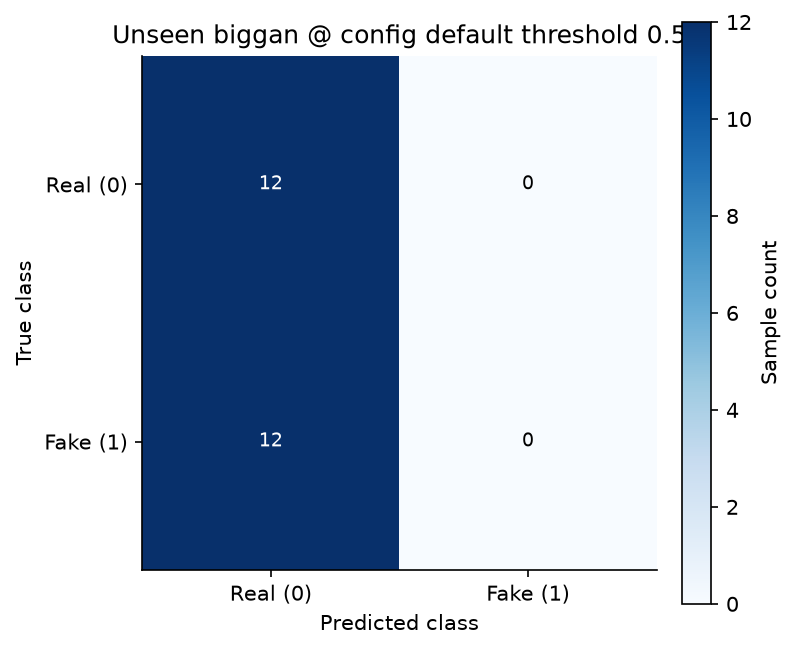

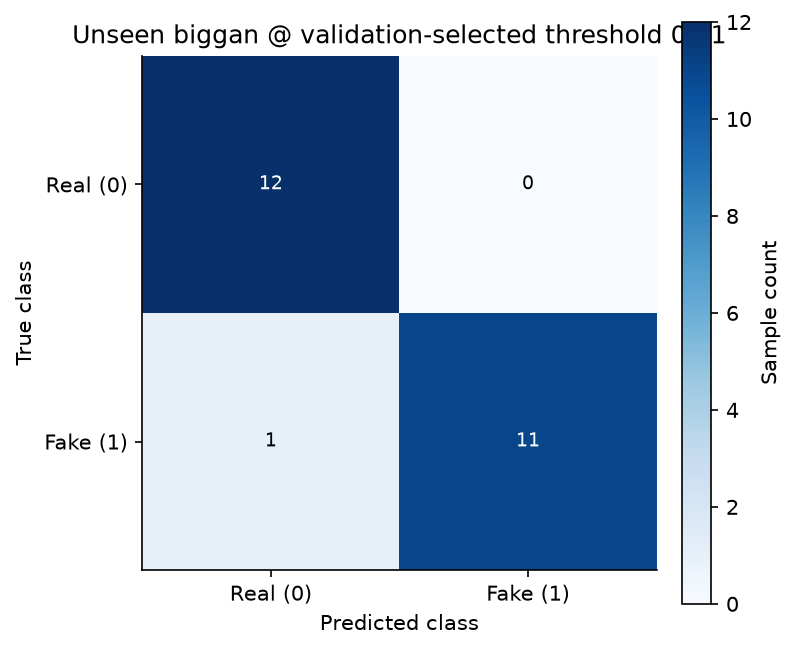

test composition: 12 held-out fakes + 12 real, prevalence 0.5


In [2]:
# Confusion matrices at each declared operating point. Counts come from the saved
# per-sample predictions; the thresholds come from the run's metrics file, so what is
# drawn is exactly what the run reported.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = json.loads((run / "unseen_generator_metrics.json").read_text())
    predictions = pd.read_csv(run / "unseen_test_predictions.csv")
    held_out = metrics["held_out_generator"]
    operating_points = {
        "config default": float(metrics["decision_threshold_default"]),
        "validation-selected": float(metrics["decision_threshold_validation_selected"]),
    }
    for name, threshold in operating_points.items():
        matrix = confusion_matrix(
            predictions["label"].tolist(),
            threshold_scores(predictions["score"].tolist(), threshold=threshold),
        )
        figure, _ = plot_confusion_matrix(
            matrix, title=f"Unseen {held_out} @ {name} threshold {threshold:g}"
        )
        display(figure)
    composition = metrics.get("final_test_composition", {})
    print(f"test composition: {composition.get('held_out_fake_count')} held-out fakes + "
          f"{composition.get('real_count')} real, prevalence "
          f"{composition.get('positive_prevalence')}")

## 2. ROC curves

ROC curves show score-ranking behaviour across thresholds. Generate them from continuous fake scores—not binary predictions—and do not plot an undefined single-class generator slice as if its AUC were zero.

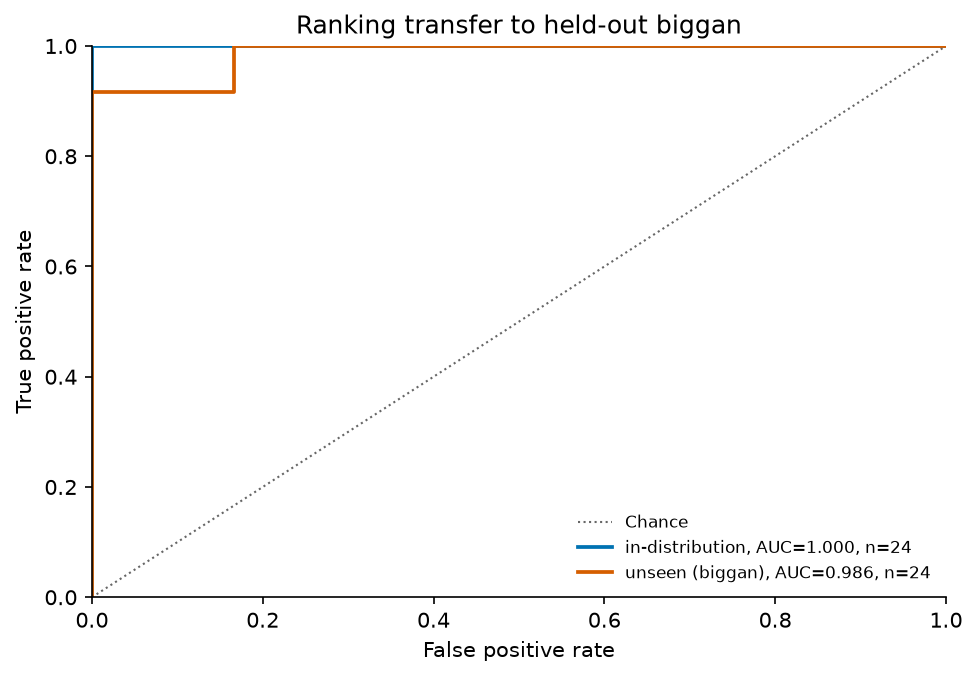

In [3]:
# ROC comparison: in-distribution versus the held-out generator, on prevalence-matched
# test sets. ROC-AUC is threshold-free, so this is the comparison least distorted by
# calibration drift on an unseen generator.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = json.loads((run / "unseen_generator_metrics.json").read_text())
    held_out = metrics["held_out_generator"]
    curves, areas, supports = {}, {}, {}
    for label, filename in (
        ("in-distribution", "in_distribution_test_predictions.csv"),
        (f"unseen ({held_out})", "unseen_test_predictions.csv"),
    ):
        path = run / filename
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        labels, scores = frame["label"].tolist(), frame["score"].tolist()
        if len(set(labels)) != 2:
            print(f"{label}: single-class slice, ROC undefined")
            continue
        computed = compute_binary_metrics(labels, scores)
        curves[label] = roc_curve_data(labels, scores)
        areas[label] = computed.roc_auc
        supports[label] = computed.support
    if curves:
        figure, _ = plot_roc_curves(
            curves, areas=areas, supports=supports,
            title=f"Ranking transfer to held-out {held_out}",
        )
        display(figure)

## 3. Precision–Recall curves

PR curves expose positive-class performance under imbalance. Include the fake-class prevalence baseline and distinguish average precision from trapezoidal area.

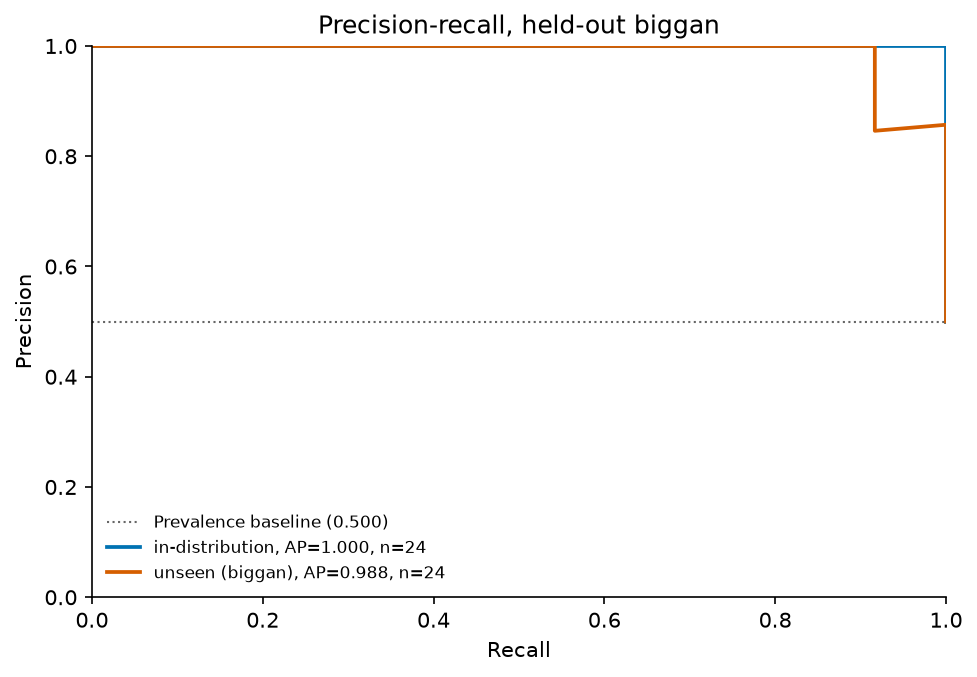

prevalence per population: [0.5, 0.5]


In [4]:
# Precision-recall against the positive-class prevalence baseline. Prevalence is taken
# from the exact plotted population, and both test sets are balanced 50/50, so the
# baseline sits at 0.5 for each.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = json.loads((run / "unseen_generator_metrics.json").read_text())
    held_out = metrics["held_out_generator"]
    curves, scores_map, supports, prevalences = {}, {}, {}, []
    for label, filename in (
        ("in-distribution", "in_distribution_test_predictions.csv"),
        (f"unseen ({held_out})", "unseen_test_predictions.csv"),
    ):
        path = run / filename
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        labels, scores = frame["label"].tolist(), frame["score"].tolist()
        if len(set(labels)) != 2:
            continue
        computed = compute_binary_metrics(labels, scores)
        curves[label] = precision_recall_curve_data(labels, scores)
        scores_map[label] = computed.average_precision
        supports[label] = computed.support
        prevalences.append(sum(labels) / len(labels))
    if curves:
        figure, _ = plot_precision_recall_curves(
            curves, prevalence=sum(prevalences) / len(prevalences),
            average_precisions=scores_map, supports=supports,
            title=f"Precision-recall, held-out {held_out}",
        )
        display(figure)
        print("prevalence per population:", [round(p, 4) for p in prevalences])

## 4. Generator-wise performance

Show whether aggregate performance hides generator-specific weakness. State whether each fake generator is paired with the same real pool; include support and do not average undefined metrics.

,generator,support,f1,roc_auc
0,real,12,0.0,NaN
1,adm,14,1.0,1.0
2,midjourney,17,1.0,1.0
3,stable_diffusion_v1_4,17,1.0,1.0


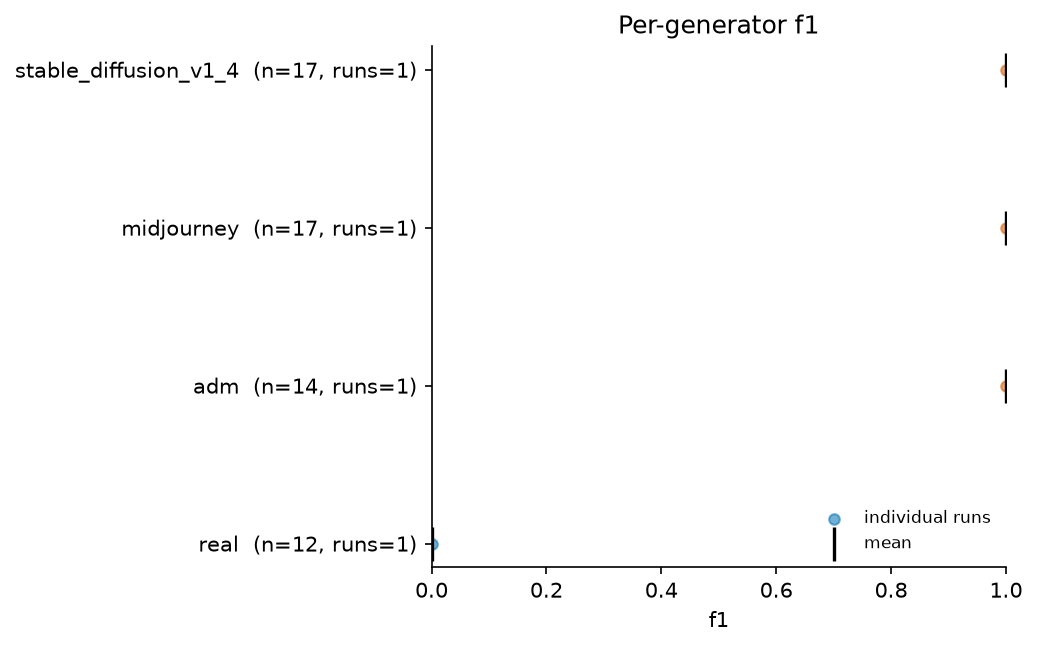

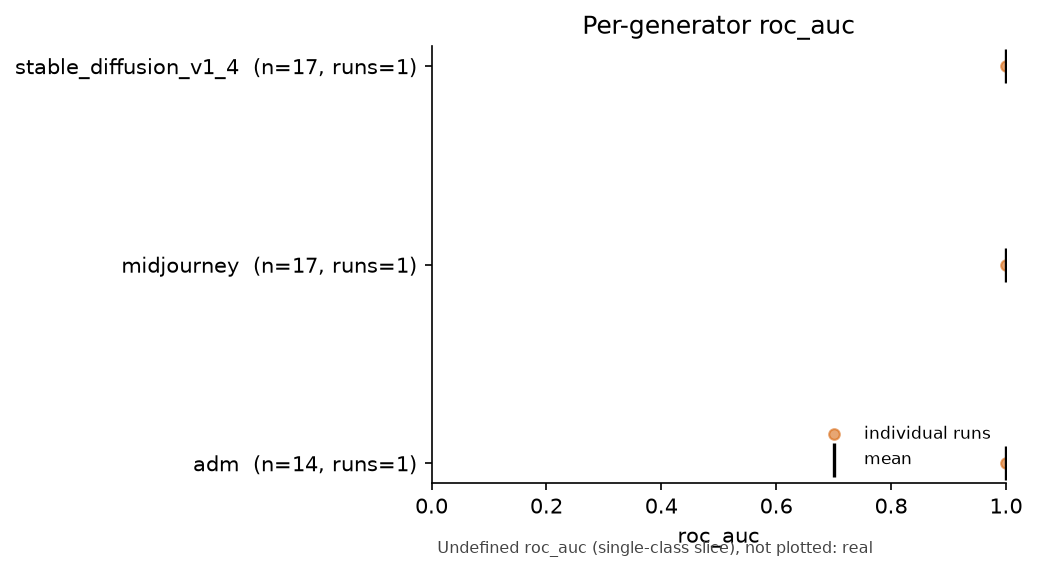

In [5]:
# Per-generator performance with support shown. Undefined single-class AUC values are
# listed as undefined rather than plotted as zero, which would read as "very bad"
# instead of "not measurable".
run = RUNS["baseline"] or RUNS["unseen_generator"]
if run is None:
    print("No completed baseline or unseen-generator run yet.")
else:
    if (run / "test_metrics.json").is_file():
        per_generator = json.loads((run / "test_metrics.json").read_text())["per_generator"]
    else:
        per_generator = json.loads(
            (run / "unseen_generator_metrics.json").read_text()
        )["in_distribution_test"]["per_generator"]
    rows = [
        {"generator": name, "support": values["support"],
         "f1": values["f1"], "roc_auc": values["roc_auc"]}
        for name, values in per_generator.items()
    ]
    display(pd.DataFrame(rows).sort_values("f1").reset_index(drop=True))
    for metric_name in ("f1", "roc_auc"):
        if any(row[metric_name] is not None for row in rows):
            figure, _ = plot_generator_performance(rows, metric_name=metric_name)
            display(figure)

## 5. Training curves

Training/validation loss and metrics diagnose underfitting, overfitting, instability, and checkpoint selection. They are diagnostic evidence, not final test performance.

,epoch,loss,split,accuracy,average_precision,f1,precision,recall,roc_auc
0,1,0.566410,train,0.651042,0.868126,0.768166,0.765517,0.770833,0.610388
1,1,0.455047,validation,0.642857,1.000000,0.782609,0.642857,1.000000,1.000000
2,2,0.236307,train,0.885417,1.000000,0.929032,0.867470,1.000000,1.000000
3,2,0.139874,validation,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,3,0.079274,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,3,0.063194,validation,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,4,0.040678,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,4,0.043110,validation,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,5,0.030949,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,5,0.037349,validation,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


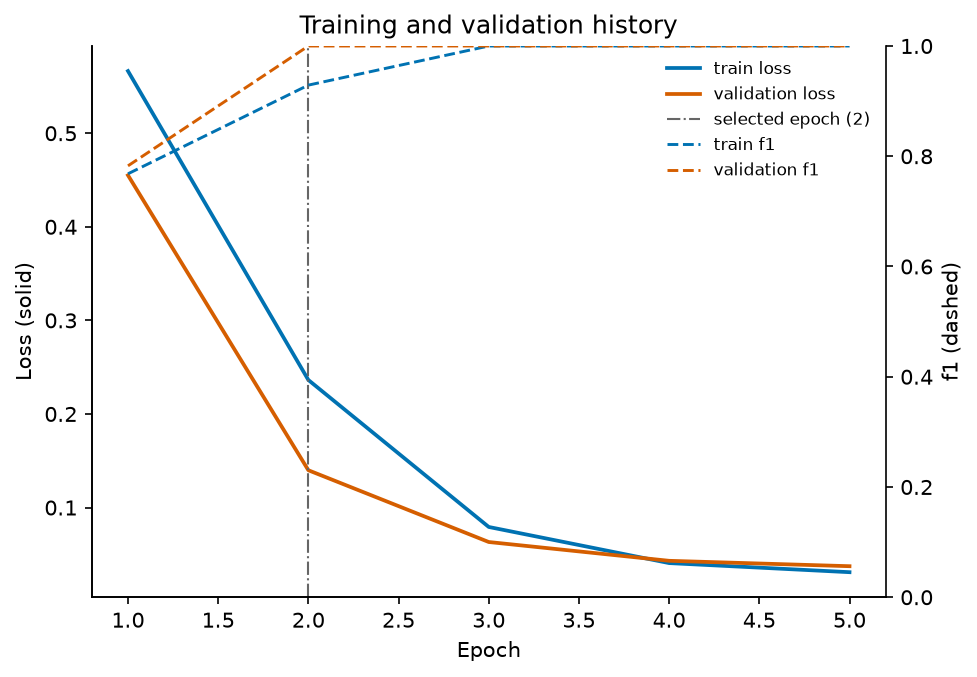

In [6]:
# Training and validation history. The validation-selected epoch is marked because that
# checkpoint, not the final epoch, produced the reported results.
run = RUNS["unseen_generator"] or RUNS["baseline"]
if run is None or not (run / "train_history.csv").is_file():
    print("No completed run with a training history yet.")
else:
    history = pd.read_csv(run / "train_history.csv")
    display(history.head(10))
    metrics_file = next(
        (name for name in ("unseen_generator_metrics.json", "test_metrics.json")
         if (run / name).is_file()), None
    )
    best_epoch = None
    if metrics_file:
        best_epoch = json.loads((run / metrics_file).read_text()).get("best_epoch")
    figure, _ = plot_training_curves(
        history.to_dict(orient="records"), metric_name="f1", best_epoch=best_epoch
    )
    display(figure)

## 6. Fine-tuning recovery and ablation comparisons

Plot the measured 0%, 5%, 10%, 20%, and 50% conditions against actual labelled sample counts. Compare head-only, last-block, and full tuning only when they share starting weights, subset IDs, final test IDs, and selection policy.


=== fine_tuning: fine_tuning-20260808T144640138049Z-6ec6cf50a2-f38d ===


,cell_id,held_out_generator,adaptation_percentage,labelled_images_consumed,roc_auc,average_precision,f1,f1_at_adaptation_threshold,f1_at_baseline_threshold,threshold_adaptation_selected,threshold_baseline_unchanged
0,zero_percent_reference,biggan,0.00,0,0.986111,0.988095,0.000000,0.956522,0.956522,NaN,0.31
1,head_only_p05_s42_t42,biggan,0.05,6,1.000000,1.000000,0.153846,0.923077,0.857143,0.33,0.31
2,head_only_p05_s123_t42,biggan,0.05,6,1.000000,1.000000,1.000000,0.800000,0.705882,0.35,0.31
3,head_only_p10_s42_t42,biggan,0.10,12,1.000000,1.000000,0.153846,0.923077,0.857143,0.33,0.31
4,head_only_p10_s123_t42,biggan,0.10,12,1.000000,1.000000,1.000000,0.800000,0.705882,0.35,0.31
5,head_only_p20_s42_t42,biggan,0.20,22,1.000000,1.000000,1.000000,0.923077,0.705882,0.39,0.31
6,head_only_p20_s123_t42,biggan,0.20,22,1.000000,1.000000,1.000000,0.827586,0.705882,0.36,0.31
7,head_only_p50_s42_t42,biggan,0.50,48,1.000000,1.000000,1.000000,0.923077,0.685714,0.40,0.31
8,head_only_p50_s123_t42,biggan,0.50,48,1.000000,1.000000,1.000000,0.888889,0.705882,0.37,0.31


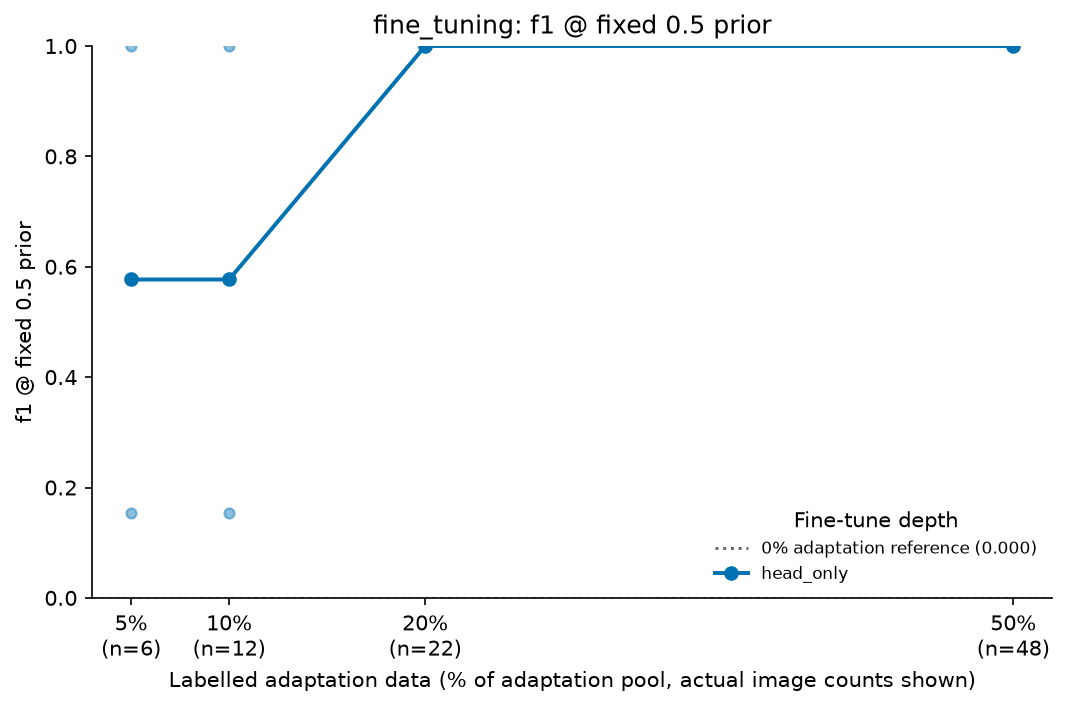

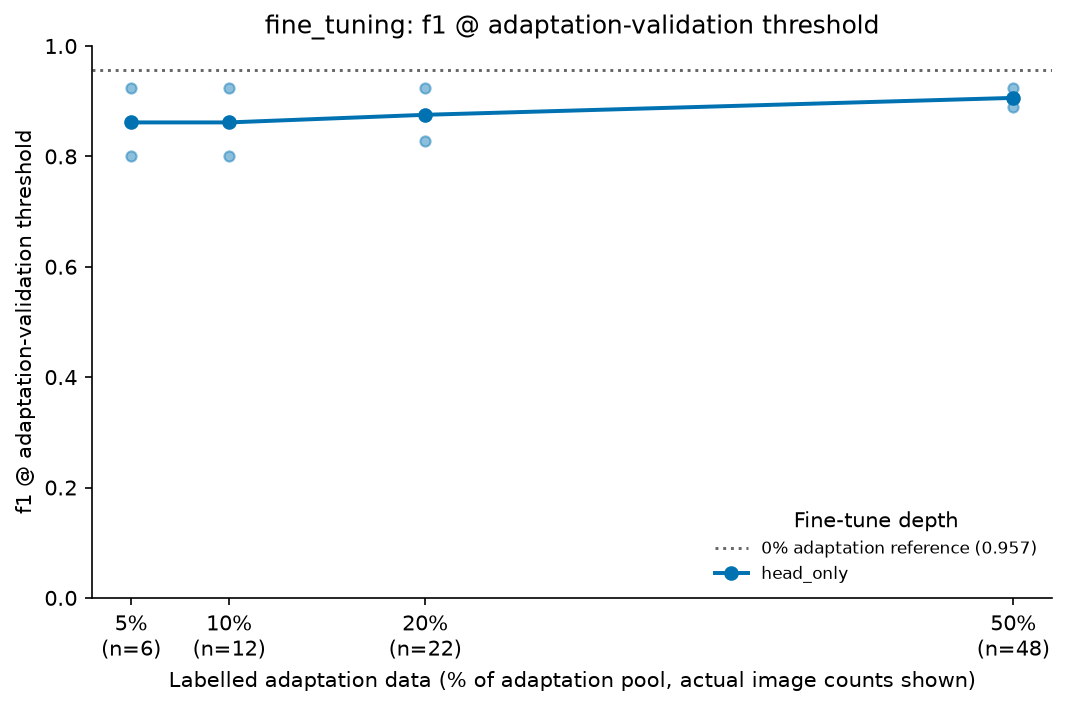

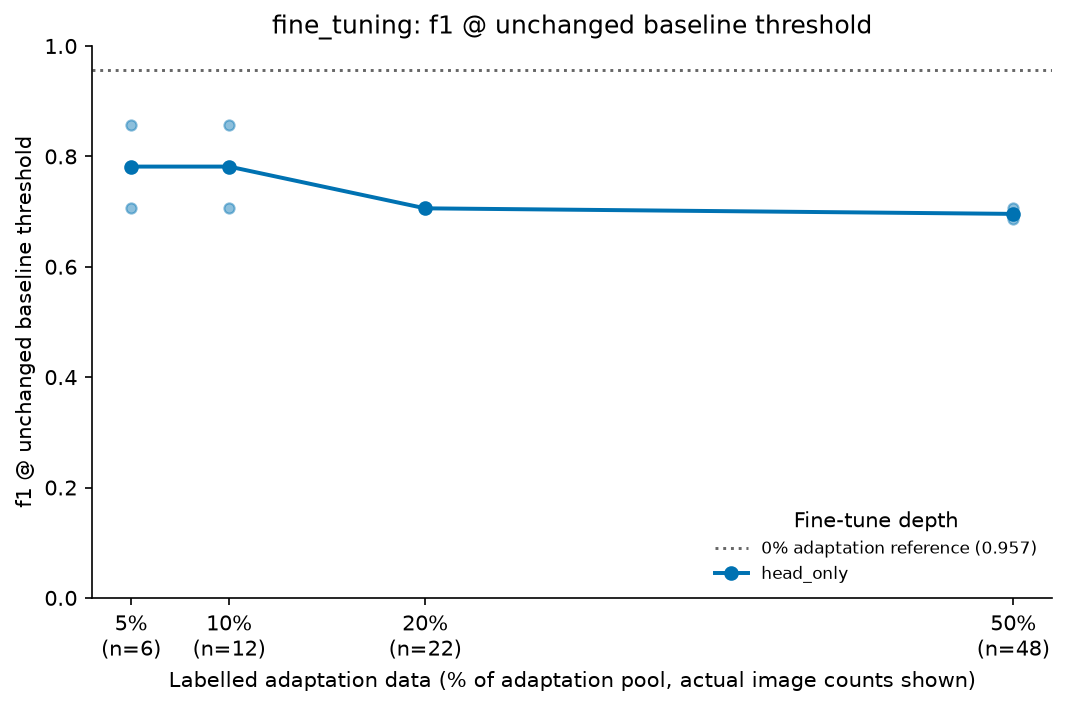

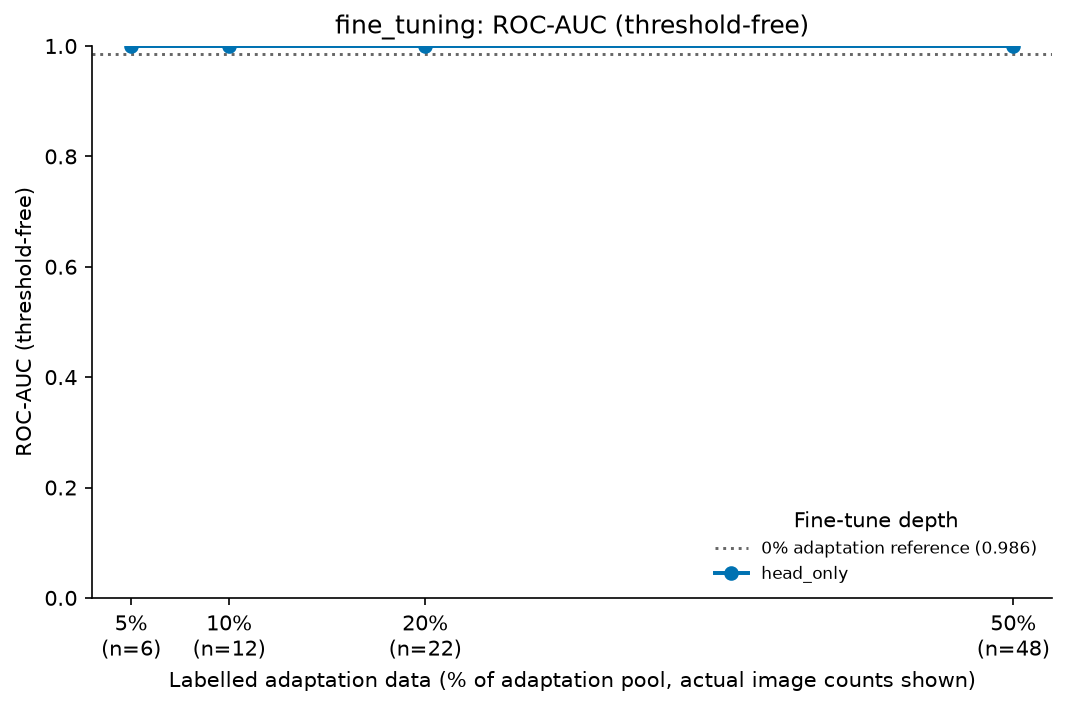

No completed ablation run yet.


In [7]:
# Recovery against labelled budget, and the depth ablation if one has been run.
#
# Each adapted model is plotted at THREE operating points. Comparing them separates
# calibration shift from genuine weight adaptation: ROC-AUC is threshold-free, so if it
# is flat while F1 climbs, the apparent recovery is a threshold effect.
for experiment in ("fine_tuning", "ablation"):
    run = RUNS[experiment]
    if run is None:
        print(f"No completed {experiment} run yet.")
        continue
    table = "recovery_cells.csv" if experiment == "fine_tuning" else "ablation_cells.csv"
    cells = pd.read_csv(run / table)
    print(f"\n=== {experiment}: {run.name} ===")
    columns = [c for c in [
        "cell_id", "held_out_generator", "adaptation_percentage", "labelled_images_consumed",
        "roc_auc", "average_precision", "f1", "f1_at_adaptation_threshold",
        "f1_at_baseline_threshold", "threshold_adaptation_selected",
        "threshold_baseline_unchanged"] if c in cells.columns]
    display(cells[columns])
    for metric_column, label in (
        ("f1", "f1 @ fixed 0.5 prior"),
        ("f1_at_adaptation_threshold", "f1 @ adaptation-validation threshold"),
        ("f1_at_baseline_threshold", "f1 @ unchanged baseline threshold"),
        ("roc_auc", "ROC-AUC (threshold-free)"),
    ):
        if metric_column not in cells.columns or cells[metric_column].isna().all():
            continue
        rows = cells.rename(columns={metric_column: "metric"}).to_dict(orient="records")
        for row in rows:
            row[metric_column] = row["metric"]
        try:
            figure, axes = plot_fine_tuning_recovery(rows, metric_name=metric_column)
            axes.set_title(f"{experiment}: {label}")
            axes.set_ylabel(label)
            display(figure)
        except ValueError as error:
            print(f"  {label}: {error}")

## Implementation checklist

- [ ] Load only saved predictions/histories from explicitly selected run IDs.
- [ ] Verify config, split, checkpoint, threshold, and sample compatibility.
- [ ] Create confusion, ROC, PR, generator, training, and recovery figures.
- [ ] Show support, actual labelled counts, seeds, and uncertainty where available.
- [ ] Use accessible, consistent styling and export vector plus high-resolution raster files.
- [ ] Record source run IDs beside every dissertation figure.